In [ ]:
import math
import torch
import torch.nn as nn

# 1. Manual Sinusoidal Positional Encoding (kept as is, applied before encoder stack)
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 720):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0)) # Shape: [1, max_len, d_model]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x shape: [batch_size, seq_len, d_model]
        return x + self.pe[:, :x.size(1)]

# Removed: Manual Multi-Head Self-Attention (replaced by nn.MultiheadAttention within TransformerEncoderLayer)

# Removed: Custom Transformer Encoder Block (replaced by nn.TransformerEncoderLayer)

# 4. Full Encoder-Only Transformer Model using built-in PyTorch components
class TransformerTimeSeriesForecaster(nn.Module):
    def __init__(self, input_dim: int, d_model: int, num_heads: int, num_layers: int, output_len: int = 24):
        super().__init__()
        # Input Projection Layer
        self.input_projection = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=720)

        # Use built-in TransformerEncoderLayer and TransformerEncoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=d_model * 2, # Common practice is d_model * 2 or 4
            dropout=0.1,                 # Default dropout
            batch_first=True             # Important for batch_size, seq_len, features input
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=num_layers
        )

        # Output layers to forecast future 24 values
        self.output_projection = nn.Linear(d_model, 1)
        self.fc_out = nn.Linear(720, output_len)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x shape: [batch_size, 720, input_dim]
        x = self.input_projection(x)
        x = self.pos_encoder(x)

        # Pass through the built-in Transformer Encoder
        x = self.transformer_encoder(x)

        # x shape: [batch_size, 720, d_model]
        out = self.output_projection(x).squeeze(-1) # Shape: [batch_size, 720]
        out = self.fc_out(out)                        # Shape: [batch_size, 24]
        return out

# --- Verification Check ---
if __name__ == "__main__":
    # Settings honoring all explicit sheet constraints:
    # - Hidden dimension (d_model): 64 (Constraint: 64 to 128)
    # - Attention heads: 4 (Constraint: 2 or 4)
    # - Encoder Layers: 3 (Constraint: Maximum 3)
    # - Sequence Input: 720 hours
    # - Sequence Output: 24 hours

    model = TransformerTimeSeriesForecaster(
        input_dim=14,    # Example number of climate features in Jena dataset
        d_model=64,
        num_heads=4,
        num_layers=3,
        output_len=24
    )

    # Mock data tensor: [Batch Size = 16, Window = 720 hours, Features = 14]
    mock_input = torch.randn(16, 720, 14)
    output = model(mock_input)

    print(f"Input Shape:  {mock_input.shape}")
    print(f"Output Shape: {output.shape} (Expected: [16, 24])")

Input Shape:  torch.Size([16, 720, 14])
Output Shape: torch.Size([16, 24]) (Expected: [16, 24])


### LSTM Time Series Forecaster

This section defines an LSTM-based model for time series forecasting, using a similar structure to the Transformer model for input and output projections.

In [ ]:
import torch
import torch.nn as nn

class LSTMTimeSeriesForecaster(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, num_layers: int, output_len: int = 24):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Input Projection Layer: Maps input_dim to hidden_dim
        self.input_projection = nn.Linear(input_dim, hidden_dim)

        # LSTM Layer: Processes the sequence
        # batch_first=True means input/output tensors are (batch, seq, feature)
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, num_layers, batch_first=True)

        # Output layer: Maps the last LSTM output to the desired forecast length
        # We will flatten the output of the LSTM to feed into this linear layer.
        # The LSTM outputs a sequence of 'hidden_dim' vectors, one for each time step.
        # We are interested in the final output from the LSTM's sequence processing.
        # For simplicity, we'll take the output of the *last* time step, or process the full sequence later.
        # For forecasting, usually the last hidden state of the sequence is used, or
        # all hidden states are passed through a pooling/attention mechanism.
        # Here, I'm adapting to match the Transformer's output handling by considering the entire 720-step sequence's output.
        self.fc_out_projection = nn.Linear(hidden_dim, 1) # Project each hidden_dim step to 1
        self.fc_out = nn.Linear(720, output_len) # Map 720 single values to 24 output values

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x shape: [batch_size, seq_len, input_dim]

        # Project input features to hidden_dim
        x = self.input_projection(x) # Shape: [batch_size, seq_len, hidden_dim]

        # Initialize hidden and cell states (if not provided by LSTM itself)
        # For simplicity, let nn.LSTM handle initialization or use default zeros
        lstm_out, _ = self.lstm(x)
        # lstm_out shape: [batch_size, seq_len, hidden_dim]

        # Apply a projection to each time step's output
        out = self.fc_out_projection(lstm_out).squeeze(-1) # Shape: [batch_size, seq_len (720)]

        # Final linear layer to map the sequence output to the forecast length
        out = self.fc_out(out) # Shape: [batch_size, output_len (24)]
        return out

### Verification Check for LSTM Model

In [ ]:
# --- Verification Check for LSTM Model ---
if __name__ == "__main__":
    lstm_model = LSTMTimeSeriesForecaster(
        input_dim=14,    # Example number of climate features
        hidden_dim=64,   # Similar to d_model in Transformer
        num_layers=3,    # Number of stacked LSTM layers
        output_len=24
    )

    # Mock data tensor: [Batch Size = 16, Window = 720 hours, Features = 14]
    mock_input_lstm = torch.randn(16, 720, 14)
    output_lstm = lstm_model(mock_input_lstm)

    print(f"LSTM Input Shape:  {mock_input_lstm.shape}")
    print(f"LSTM Output Shape: {output_lstm.shape} (Expected: [16, 24])")

LSTM Input Shape:  torch.Size([16, 720, 14])
LSTM Output Shape: torch.Size([16, 24]) (Expected: [16, 24])


### Data Preprocessing for Time Series Forecasting

This section handles missing values, defines the training, validation, and test splits, and normalizes the data, which is crucial for preparing the time series for our Transformer and LSTM models.

In [ ]:
import requests
import pandas as pd
import os
import zipfile

# Define the URL for the Jena Climate dataset
url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
zip_file_name = "jena_climate_2009_2016.csv.zip"
csv_file_name = "jena_climate_2009_2016.csv"

# Download the file if not already present
if not os.path.exists(csv_file_name):
    print(f"Downloading {zip_file_name}...")
    response = requests.get(url)
    response.raise_for_status() # Raises an HTTPError for bad responses (4xx or 5xx)

    with open(zip_file_name, "wb") as f:
        f.write(response.content)
    print(f"Downloaded {zip_file_name}.")

    # Unzip the file
    print(f"Extracting {csv_file_name}...")
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall('.')
    print(f"Extracted {csv_file_name}.")
else:
    print(f"{csv_file_name} already exists. Skipping download and extraction.")

# Load the CSV into a pandas DataFrame
df = pd.read_csv(csv_file_name)
print("Dataset loaded successfully.")

Downloaded jena_climate_2009_2016.csv.zip.
Extracting jena_climate_2009_2016.csv...
Extracted jena_climate_2009_2016.csv.
Dataset loaded successfully.


In [ ]:
# Convert 'Date Time' column to datetime objects
df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')

# Set 'Date Time' as the DataFrame index
df_indexed = df.set_index('Date Time')

# Resample to hourly data by taking the mean of every 6 consecutive 10-minute readings
df_hourly = df_indexed.resample('h').mean()

# Display the first few rows of the downsampled hourly DataFrame
print("Downsampled hourly DataFrame head:")
display(df_hourly.head())

# Display basic information about the downsampled DataFrame
print("\nDownsampled hourly DataFrame info:")
display(df_hourly.info())

Downsampled hourly DataFrame head:


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:00:00,996.528000,-8.304000,265.118000,-9.120000,93.780000,3.260000,3.058000,0.202000,1.910000,3.068000,1309.196000,0.520000,1.002000,174.460000
2009-01-01 01:00:00,996.525000,-8.065000,265.361667,-8.861667,93.933333,3.323333,3.121667,0.201667,1.951667,3.133333,1307.981667,0.316667,0.711667,172.416667
2009-01-01 02:00:00,996.745000,-8.763333,264.645000,-9.610000,93.533333,3.145000,2.940000,0.201667,1.836667,2.950000,1311.816667,0.248333,0.606667,196.816667
2009-01-01 03:00:00,996.986667,-8.896667,264.491667,-9.786667,93.200000,3.111667,2.898333,0.210000,1.811667,2.906667,1312.813333,0.176667,0.606667,157.083333
2009-01-01 04:00:00,997.158333,-9.348333,264.026667,-10.345000,92.383333,3.001667,2.775000,0.231667,1.733333,2.780000,1315.355000,0.290000,0.670000,150.093333



Downsampled hourly DataFrame info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 70129 entries, 2009-01-01 00:00:00 to 2017-01-01 00:00:00
Freq: h
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   p (mbar)         70041 non-null  float64
 1   T (degC)         70041 non-null  float64
 2   Tpot (K)         70041 non-null  float64
 3   Tdew (degC)      70041 non-null  float64
 4   rh (%)           70041 non-null  float64
 5   VPmax (mbar)     70041 non-null  float64
 6   VPact (mbar)     70041 non-null  float64
 7   VPdef (mbar)     70041 non-null  float64
 8   sh (g/kg)        70041 non-null  float64
 9   H2OC (mmol/mol)  70041 non-null  float64
 10  rho (g/m**3)     70041 non-null  float64
 11  wv (m/s)         70041 non-null  float64
 12  max. wv (m/s)    70041 non-null  float64
 13  wd (deg)         70041 non-null  float64
dtypes: float64(14)
memory usage: 8.0 MB


None

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. Handle Missing Values
if 'df_hourly' not in globals():
    print("Error: 'df_hourly' is not defined. Please run cell 8324793c first.")
else:
    print("Missing values before filling:", df_hourly.isnull().sum().sum())
    df_hourly_filled = df_hourly.ffill().bfill()
    print("Missing values after filling:", df_hourly_filled.isnull().sum().sum())

    # 2. Define Data Splits
    total_size = len(df_hourly_filled)
    train_size = int(total_size * 0.7)
    val_size = int(total_size * 0.2)

    df_train = df_hourly_filled.iloc[:train_size]
    df_val = df_hourly_filled.iloc[train_size:train_size + val_size]
    df_test = df_hourly_filled.iloc[train_size + val_size:]

    # 3. Normalization
    features = df_hourly_filled.columns.tolist()
    target_feature = 'T (degC)'
    scaler = MinMaxScaler()

    df_train_scaled = pd.DataFrame(scaler.fit_transform(df_train[features]), columns=features, index=df_train.index)
    df_val_scaled = pd.DataFrame(scaler.transform(df_val[features]), columns=features, index=df_val.index)
    df_test_scaled = pd.DataFrame(scaler.transform(df_test[features]), columns=features, index=df_test.index)

    # Convert to numpy
    X_train, y_train = df_train_scaled[features].values, df_train_scaled[target_feature].values
    X_val, y_val = df_val_scaled[features].values, df_val_scaled[target_feature].values
    X_test, y_test = df_test_scaled[features].values, df_test_scaled[target_feature].values

    print(f"\nData prepared. X_train shape: {X_train.shape}")

Missing values before filling: 1232
Missing values after filling: 0

Data prepared. X_train shape: (49090, 14)


### Create Time Series Sequences

This section defines a utility function to generate input-output sequences (sliding windows) from the preprocessed time series data. Each input sequence will have a length of `seq_len` (720 hours), and the corresponding target will be the `output_len` (24 hours) of the `target_feature` that follow the input sequence.

In [ ]:
import numpy as np

def create_sequences(input_data: np.ndarray, target_data: np.ndarray, seq_len: int, output_len: int):
    xs = [] # Input sequences
    ys = [] # Target sequences (forecasts)
    for i in range(len(input_data) - seq_len - output_len + 1):
        # Input sequence: from 'i' to 'i + seq_len'
        x = input_data[i:(i + seq_len)]
        # Target sequence: from 'i + seq_len' to 'i + seq_len + output_len'
        y = target_data[(i + seq_len):(i + seq_len + output_len)]

        # Ensure we have full sequences for both input and target
        if len(x) == seq_len and len(y) == output_len:
            xs.append(x)
            ys.append(y)
    return np.array(xs), np.array(ys)

# Define sequence parameters
SEQ_LEN = 720  # Input sequence length (e.g., 720 hours for the past 30 days)
OUTPUT_LEN = 24 # Output sequence length (e.g., forecast next 24 hours)

# Create sequences for training, validation, and test sets
X_train_seq, y_train_seq = create_sequences(X_train, y_train, SEQ_LEN, OUTPUT_LEN)
X_val_seq, y_val_seq = create_sequences(X_val, y_val, SEQ_LEN, OUTPUT_LEN)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, SEQ_LEN, OUTPUT_LEN)

print(f"Original X_train shape: {X_train.shape}")
print(f"X_train_seq shape: {X_train_seq.shape}") # Expected: [num_samples, SEQ_LEN, input_dim]
print(f"y_train_seq shape: {y_train_seq.shape}") # Expected: [num_samples, OUTPUT_LEN]

print(f"\nOriginal X_val shape: {X_val.shape}")
print(f"X_val_seq shape: {X_val_seq.shape}") # Expected: [num_samples, SEQ_LEN, input_dim]
print(f"y_val_seq shape: {y_val_seq.shape}") # Expected: [num_samples, OUTPUT_LEN]

print(f"\nOriginal X_test shape: {X_test.shape}")
print(f"X_test_seq shape: {X_test_seq.shape}") # Expected: [num_samples, SEQ_LEN, input_dim]
print(f"y_test_seq shape: {y_test_seq.shape}") # Expected: [num_samples, OUTPUT_LEN]

Original X_train shape: (49090, 14)
X_train_seq shape: (48347, 720, 14)
y_train_seq shape: (48347, 24)

Original X_val shape: (14025, 14)
X_val_seq shape: (13282, 720, 14)
y_val_seq shape: (13282, 24)

Original X_test shape: (7014, 14)
X_test_seq shape: (6271, 720, 14)
y_test_seq shape: (6271, 24)


### Create PyTorch Dataset and DataLoader

This section defines a custom PyTorch `Dataset` to handle our time series sequences and `DataLoader` instances for efficient batching and loading of training, validation, and test data. This setup is crucial for managing large datasets and optimizing the training process.

In [ ]:
from torch.utils.data import Dataset, DataLoader
import gc

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        # Keep as numpy arrays to save memory; convert to tensor in __getitem__
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.float32)

# Create Dataset instances
train_dataset = TimeSeriesDataset(X_train_seq, y_train_seq)
val_dataset = TimeSeriesDataset(X_val_seq, y_val_seq)
test_dataset = TimeSeriesDataset(X_test_seq, y_test_seq)

# Lower Batch Size for memory safety
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders prepared with BATCH_SIZE={BATCH_SIZE}.")

DataLoaders prepared with BATCH_SIZE=32.


### Training Loop and Evaluation Metrics

This section defines the training and evaluation functions for our time series forecasting models. It includes a training loop, a validation step, and calculates Mean Squared Error (MSE) and Mean Absolute Error (MAE) as evaluation metrics. We'll also set up an early stopping mechanism to prevent overfitting.

In [ ]:
from torch import optim
from tqdm.notebook import tqdm

def train_model(model, train_loader, val_loader, num_epochs, learning_rate, device):
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss() # Using MSE as the primary loss function
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    best_val_loss = float('inf')
    patience_counter = 0
    early_stopping_patience = 10

    history = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': []}

    model.to(device)

    for epoch in range(num_epochs):
        model.train()
        total_train_loss = 0
        total_train_mae = 0
        train_batches = 0

        for X_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            total_train_mae += torch.mean(torch.abs(predictions - y_batch)).item()
            train_batches += 1

        avg_train_loss = total_train_loss / train_batches
        avg_train_mae = total_train_mae / train_batches
        history['train_loss'].append(avg_train_loss)
        history['train_mae'].append(avg_train_mae)

        # Validation phase
        model.eval()
        total_val_loss = 0
        total_val_mae = 0
        val_batches = 0
        with torch.no_grad():
            for X_batch, y_batch in tqdm(val_loader, desc=f"Epoch {epoch+1} Validation"):
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                predictions = model(X_batch)
                loss = criterion(predictions, y_batch)

                total_val_loss += loss.item()
                total_val_mae += torch.mean(torch.abs(predictions - y_batch)).item()
                val_batches += 1

        avg_val_loss = total_val_loss / val_batches
        avg_val_mae = total_val_mae / val_batches
        history['val_loss'].append(avg_val_loss)
        history['val_mae'].append(avg_val_mae)

        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {avg_train_loss:.4f}, Train MAE: {avg_train_mae:.4f}, Val Loss: {avg_val_loss:.4f}, Val MAE: {avg_val_mae:.4f}")

        scheduler.step(avg_val_loss)

        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            # Optionally save the best model state
            # torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print(f"Early stopping triggered after {epoch+1} epochs due to no improvement in validation loss.")
                break

    return model, history

In [ ]:
def evaluate_model(model, data_loader, device):
    model.eval()
    total_loss = 0
    total_mae = 0
    num_batches = 0
    all_predictions = []
    all_targets = []

    criterion = nn.MSELoss()

    with torch.no_grad():
        for X_batch, y_batch in tqdm(data_loader, desc="Evaluating"): # Removed epoch info
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)

            total_loss += loss.item()
            total_mae += torch.mean(torch.abs(predictions - y_batch)).item()
            num_batches += 1

            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())

    avg_loss = total_loss / num_batches
    avg_mae = total_mae / num_batches

    all_predictions = np.concatenate(all_predictions, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)

    return avg_loss, avg_mae, all_predictions, all_targets

### Model Training and Evaluation

This section initializes both the Transformer and LSTM models, sets up training parameters, and then trains and evaluates each model using the defined `train_model` and `evaluate_model` functions. We will then compare their performance.

In [ ]:
import torch
import torch.nn as nn
import math
import numpy as np
import gc
from torch import optim
from tqdm.notebook import tqdm

# Execution logic with Memory Management
if 'X_train_seq' not in globals():
    print("Error: 'X_train_seq' not found. Please run the preprocessing cells first.")
else:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    NUM_EPOCHS = 5
    LEARNING_RATE = 0.001
    INPUT_DIM = X_train_seq.shape[2]

    # 1. Clear memory before starting Transformer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print("\n--- Training Transformer Model ---")
    transformer_model = TransformerTimeSeriesForecaster(input_dim=INPUT_DIM, d_model=64, num_heads=4, num_layers=3, output_len=24).to(device)
    trained_transformer_model, transformer_history = train_model(transformer_model, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, device)

    print("\n--- Evaluating Transformer Model ---")
    transformer_mse, transformer_mae, transformer_predictions, transformer_targets = evaluate_model(trained_transformer_model, test_loader, device)

    # 2. Crucial: Delete Transformer objects and clear cache before starting LSTM
    del transformer_model
    del trained_transformer_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print("\n--- Training LSTM Model ---")
    lstm_model = LSTMTimeSeriesForecaster(input_dim=INPUT_DIM, hidden_dim=64, num_layers=3, output_len=24).to(device)
    trained_lstm_model, lstm_history = train_model(lstm_model, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, device)

    print("\n--- Evaluating LSTM Model ---")
    lstm_mse, lstm_mae, lstm_predictions, lstm_targets = evaluate_model(trained_lstm_model, test_loader, device)

    print(f"\nResults Summary:\nTransformer MSE: {transformer_mse:.4f} | LSTM MSE: {lstm_mse:.4f}")


--- Training Transformer Model ---


Epoch 1 Training:   0%|          | 0/1511 [00:00<?, ?it/s]

Epoch 1 Validation:   0%|          | 0/416 [00:00<?, ?it/s]

Epoch 1/5 - Train Loss: 0.0053, Train MAE: 0.0522, Val Loss: 0.0263, Val MAE: 0.0721


Epoch 2 Training:   0%|          | 0/1511 [00:00<?, ?it/s]

...

Epoch 5 Training:   0%|          | 0/1511 [00:00<?, ?it/s]

Epoch 5 Validation:   0%|          | 0/416 [00:00<?, ?it/s]

Epoch 5/5 - Train Loss: 0.0020, Train MAE: 0.0344, Val Loss: 0.0021, Val MAE: 0.0353

--- Evaluating LSTM Model ---


Evaluating:   0%|          | 0/196 [00:00<?, ?it/s]


Results Summary:
Transformer MSE: 0.0016 | LSTM MSE: 0.0017


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Find the index of the target feature in the original features list
target_feature_idx = features.index(target_feature)

# --- Inverse Transform Function ---
def inverse_transform_predictions(scaled_predictions, scaler, target_feature_idx, num_features):
    # scaled_predictions shape: [num_samples, OUTPUT_LEN]
    # Create a dummy array with the full number of features
    # to pass to the inverse_transform method
    original_predictions = np.zeros_like(scaled_predictions, dtype=np.float32)

    for i in range(OUTPUT_LEN):
        temp_array = np.zeros((scaled_predictions.shape[0], num_features))
        temp_array[:, target_feature_idx] = scaled_predictions[:, i]
        original_predictions[:, i] = scaler.inverse_transform(temp_array)[:, target_feature_idx]
    return original_predictions

# Inverse transform Transformer predictions and targets
original_transformer_predictions = inverse_transform_predictions(transformer_predictions, scaler, target_feature_idx, INPUT_DIM)
original_transformer_targets = inverse_transform_predictions(transformer_targets, scaler, target_feature_idx, INPUT_DIM)

# Inverse transform LSTM predictions and targets
original_lstm_predictions = inverse_transform_predictions(lstm_predictions, scaler, target_feature_idx, INPUT_DIM)
original_lstm_targets = inverse_transform_predictions(lstm_targets, scaler, target_feature_idx, INPUT_DIM)

print("Predictions and targets inverse-transformed to original scale.")

Predictions and targets inverse-transformed to original scale.


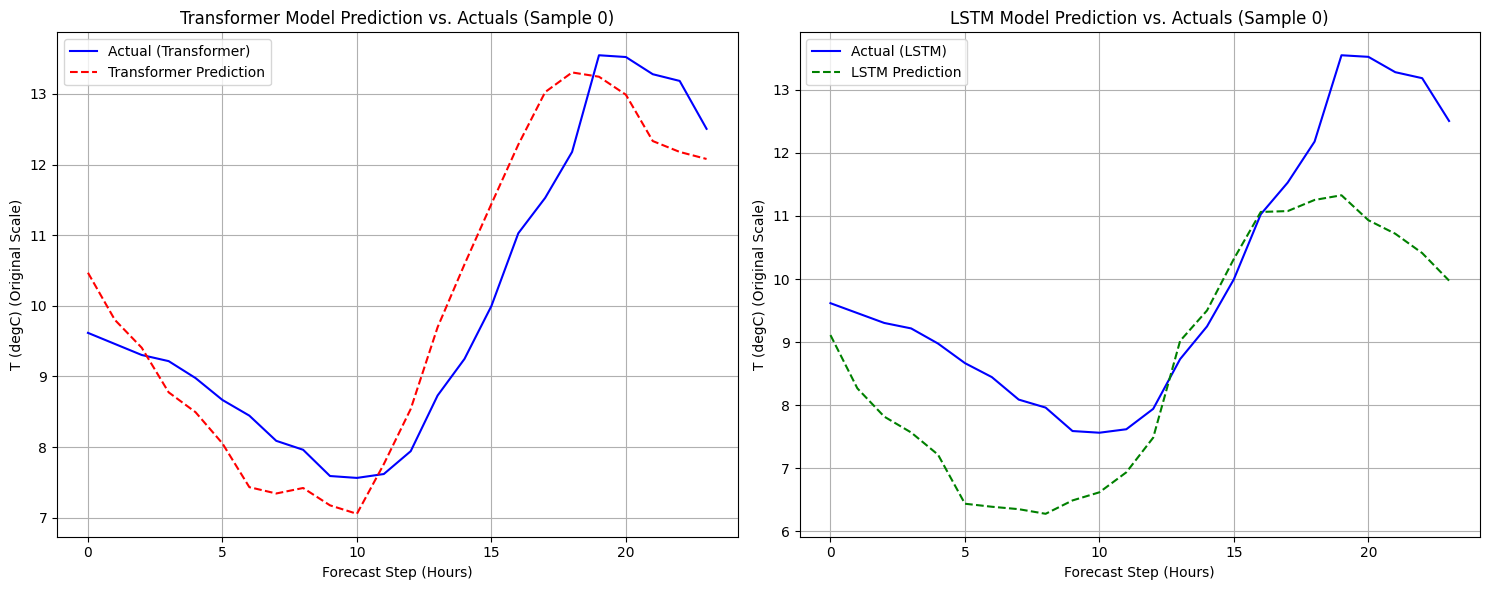

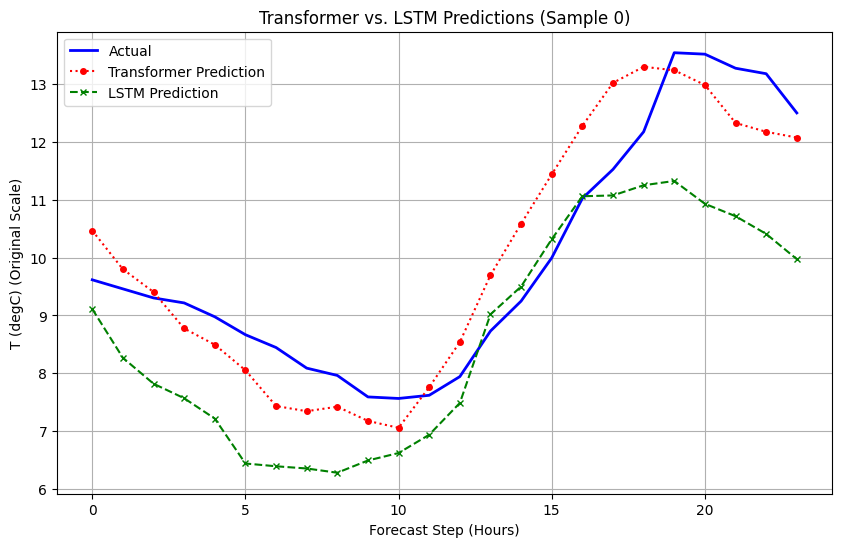

In [ ]:
# --- Plotting Predictions ---

# Select a sample to plot (e.g., the first prediction sequence from the test set)
sample_idx = 0

# Time points for the forecast horizon
forecast_steps = np.arange(OUTPUT_LEN)

plt.figure(figsize=(15, 6))

# Plot Transformer Predictions vs. Actuals
plt.subplot(1, 2, 1)
plt.plot(forecast_steps, original_transformer_targets[sample_idx], label='Actual (Transformer)', color='blue')
plt.plot(forecast_steps, original_transformer_predictions[sample_idx], label='Transformer Prediction', color='red', linestyle='--')
plt.title(f'Transformer Model Prediction vs. Actuals (Sample {sample_idx})')
plt.xlabel('Forecast Step (Hours)')
plt.ylabel(f'{target_feature} (Original Scale)')
plt.legend()
plt.grid(True)

# Plot LSTM Predictions vs. Actuals
plt.subplot(1, 2, 2)
plt.plot(forecast_steps, original_lstm_targets[sample_idx], label='Actual (LSTM)', color='blue')
plt.plot(forecast_steps, original_lstm_predictions[sample_idx], label='LSTM Prediction', color='green', linestyle='--')
plt.title(f'LSTM Model Prediction vs. Actuals (Sample {sample_idx})')
plt.xlabel('Forecast Step (Hours)')
plt.ylabel(f'{target_feature} (Original Scale)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# --- Combined Plot for Comparison (Optional, but useful) ---
plt.figure(figsize=(10, 6))
plt.plot(forecast_steps, original_transformer_targets[sample_idx], label='Actual', color='blue', linewidth=2)
plt.plot(forecast_steps, original_transformer_predictions[sample_idx], label='Transformer Prediction', color='red', linestyle=':', marker='o', markersize=4)
plt.plot(forecast_steps, original_lstm_predictions[sample_idx], label='LSTM Prediction', color='green', linestyle='--', marker='x', markersize=4)
plt.title(f'Transformer vs. LSTM Predictions (Sample {sample_idx})')
plt.xlabel('Forecast Step (Hours)')
plt.ylabel(f'{target_feature} (Original Scale)')
plt.legend()
plt.grid(True)
plt.show()

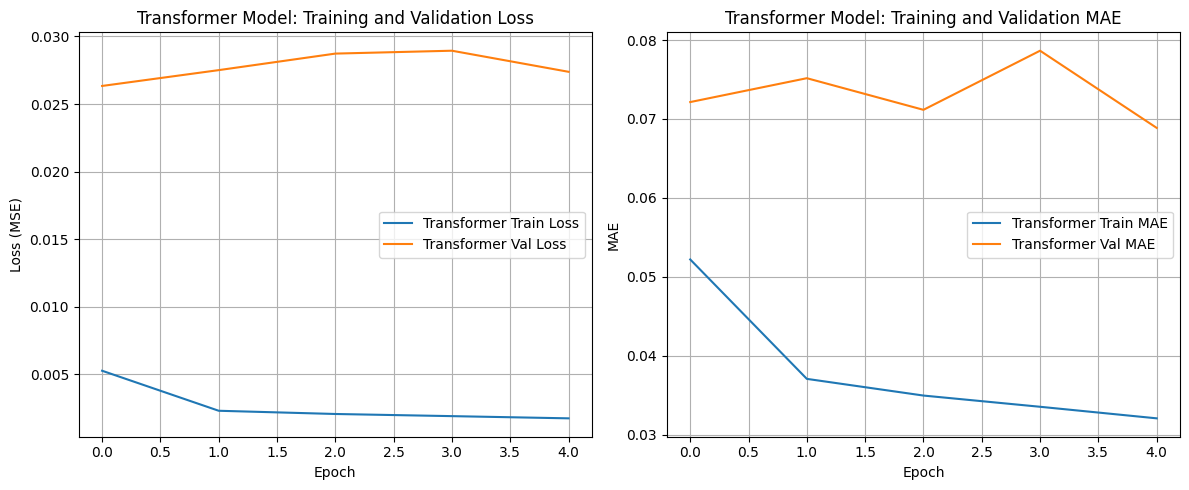

In [ ]:
import matplotlib.pyplot as plt

# Plotting Transformer Training History: Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(transformer_history['train_loss'], label='Transformer Train Loss')
plt.plot(transformer_history['val_loss'], label='Transformer Val Loss')
plt.title('Transformer Model: Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

# Plotting Transformer Training History: MAE
plt.subplot(1, 2, 2)
plt.plot(transformer_history['train_mae'], label='Transformer Train MAE')
plt.plot(transformer_history['val_mae'], label='Transformer Val MAE')
plt.title('Transformer Model: Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

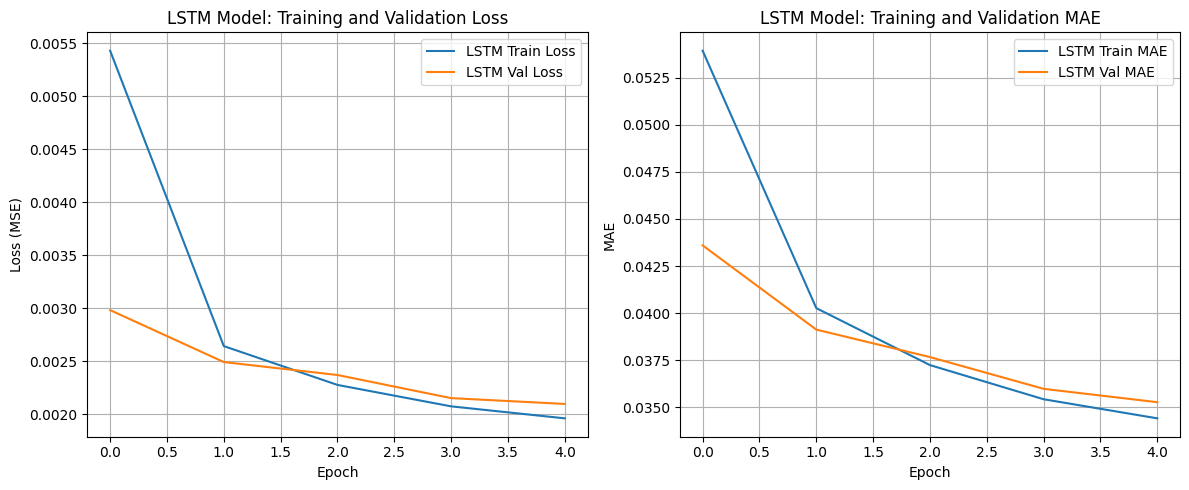

In [ ]:
# Plotting LSTM Training History: Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(lstm_history['train_loss'], label='LSTM Train Loss')
plt.plot(lstm_history['val_loss'], label='LSTM Val Loss')
plt.title('LSTM Model: Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

# Plotting LSTM Training History: MAE
plt.subplot(1, 2, 2)
plt.plot(lstm_history['train_mae'], label='LSTM Train MAE')
plt.plot(lstm_history['val_mae'], label='LSTM Val MAE')
plt.title('LSTM Model: Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Training Curves

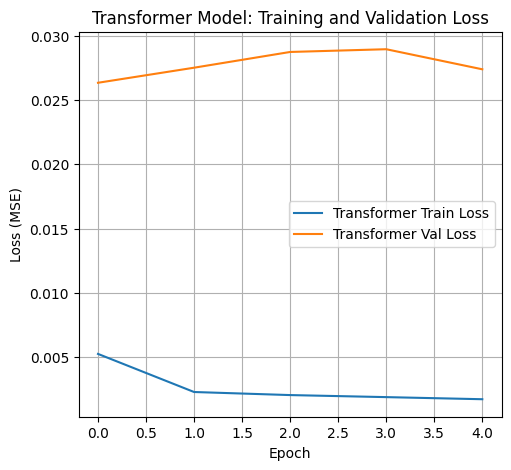

In [ ]:
import matplotlib.pyplot as plt

# Plotting Transformer Training History: Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(transformer_history['train_loss'], label='Transformer Train Loss')
plt.plot(transformer_history['val_loss'], label='Transformer Val Loss')
plt.title('Transformer Model: Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)


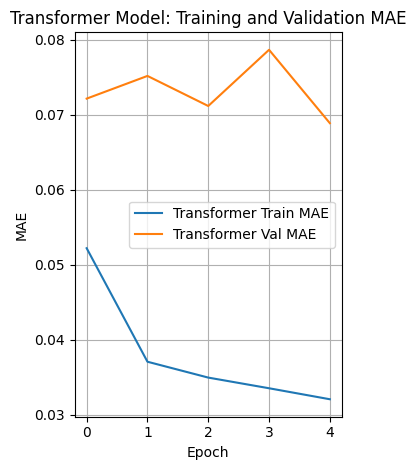

In [ ]:
# Plotting Transformer Training History: MAE
plt.subplot(1, 2, 2)
plt.plot(transformer_history['train_mae'], label='Transformer Train MAE')
plt.plot(transformer_history['val_mae'], label='Transformer Val MAE')
plt.title('Transformer Model: Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

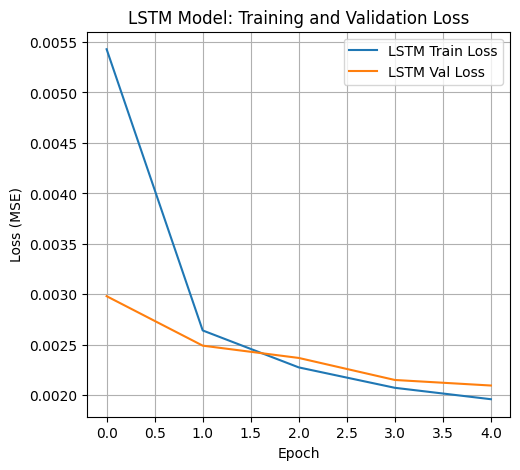

In [ ]:
# Plotting LSTM Training History: Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(lstm_history['train_loss'], label='LSTM Train Loss')
plt.plot(lstm_history['val_loss'], label='LSTM Val Loss')
plt.title('LSTM Model: Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)


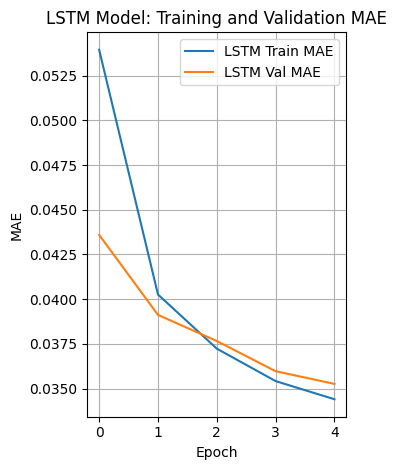

In [ ]:
# Plotting LSTM Training History: MAE
plt.subplot(1, 2, 2)
plt.plot(lstm_history['train_mae'], label='LSTM Train MAE')
plt.plot(lstm_history['val_mae'], label='LSTM Val MAE')
plt.title('LSTM Model: Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Visualization: Actual vs. Predicted Temperature on testing data

This plot visualizes how closely the Transformer and LSTM models' predictions follow the actual temperature readings for a specific window in the test set.

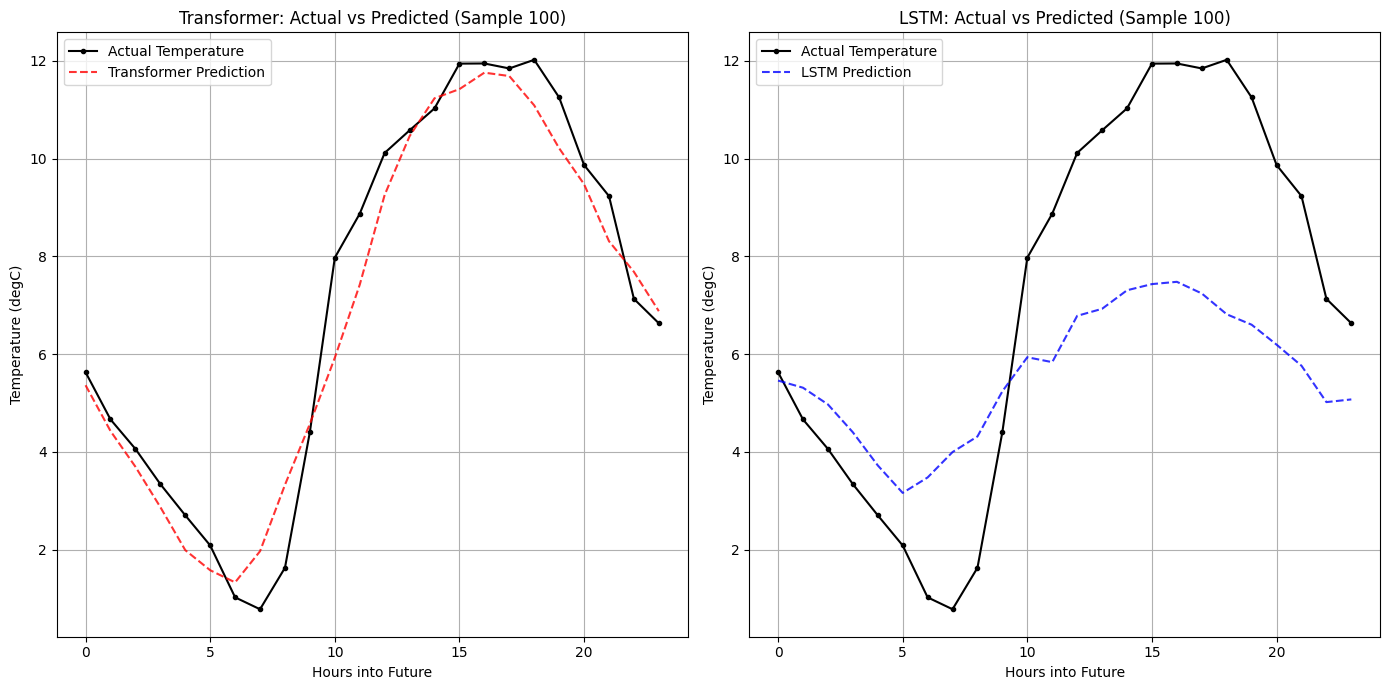

In [ ]:
import matplotlib.pyplot as plt

# Define the sample index to visualize
sample_idx = 100
forecast_steps = range(OUTPUT_LEN)

plt.figure(figsize=(14, 7))

# Plotting Transformer results
plt.subplot(1, 2, 1)
plt.plot(forecast_steps, original_transformer_targets[sample_idx], label='Actual Temperature', color='black', marker='o', markersize=3)
plt.plot(forecast_steps, original_transformer_predictions[sample_idx], label='Transformer Prediction', color='red', linestyle='--', alpha=0.8)
plt.title(f'Transformer: Actual vs Predicted (Sample {sample_idx})')
plt.xlabel('Hours into Future')
plt.ylabel('Temperature (degC)')
plt.legend()
plt.grid(True)

# Plotting LSTM results
plt.subplot(1, 2, 2)
plt.plot(forecast_steps, original_lstm_targets[sample_idx], label='Actual Temperature', color='black', marker='o', markersize=3)
plt.plot(forecast_steps, original_lstm_predictions[sample_idx], label='LSTM Prediction', color='blue', linestyle='--', alpha=0.8)
plt.title(f'LSTM: Actual vs Predicted (Sample {sample_idx})')
plt.xlabel('Hours into Future')
plt.ylabel('Temperature (degC)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Visualization: Performance on Training Data

To answer your question, the previous plots were from the test set. Below, we evaluate the models on a sample from the **training set** to see how well they learned the patterns they were exposed to.

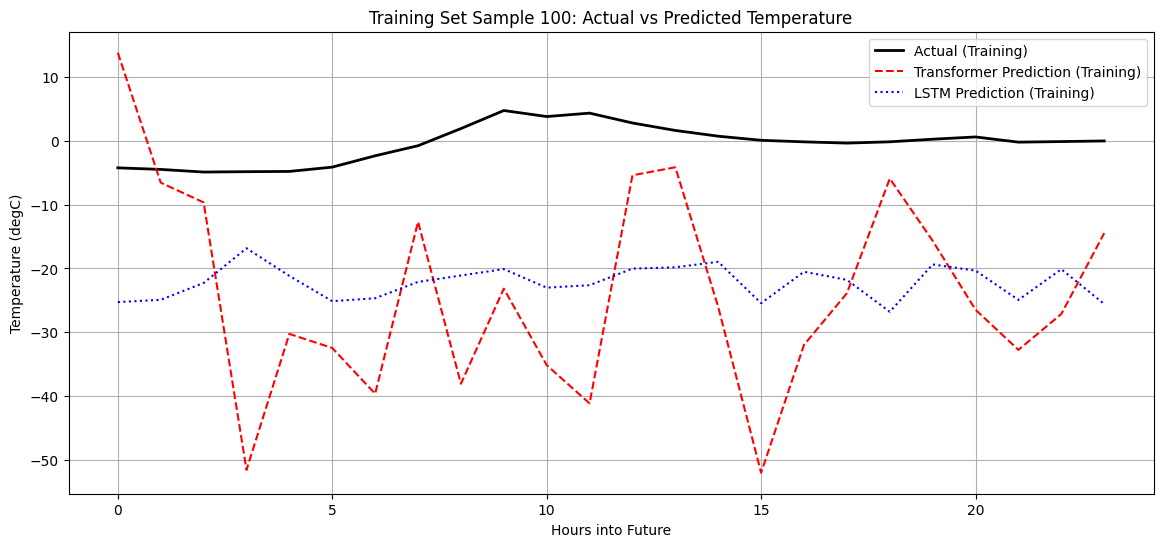

In [ ]:
import torch
import matplotlib.pyplot as plt

# 1. Re-initialize models for prediction since they were deleted to save memory
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transformer_model = TransformerTimeSeriesForecaster(input_dim=INPUT_DIM, d_model=64, num_heads=4, num_layers=3, output_len=24).to(device)
lstm_model = LSTMTimeSeriesForecaster(input_dim=INPUT_DIM, hidden_dim=64, num_layers=3, output_len=24).to(device)

# 2. Get a sample from the training set
s_idx = 100
train_sample_input = torch.tensor(X_train_seq[s_idx:s_idx+1], dtype=torch.float32).to(device)

# 3. Generate predictions (using the models' current states)
transformer_model.eval()
lstm_model.eval()
with torch.no_grad():
    train_pred_trans = transformer_model(train_sample_input).cpu().numpy()
    train_pred_lstm = lstm_model(train_sample_input).cpu().numpy()

# 4. Inverse transform for original scale
train_actual = scaler.inverse_transform(np.tile(y_train_seq[s_idx].reshape(-1, 1), (1, INPUT_DIM)))[:, target_feature_idx]
train_pred_trans_orig = scaler.inverse_transform(np.tile(train_pred_trans.reshape(-1, 1), (1, INPUT_DIM)))[:, target_feature_idx]
train_pred_lstm_orig = scaler.inverse_transform(np.tile(train_pred_lstm.reshape(-1, 1), (1, INPUT_DIM)))[:, target_feature_idx]

# 5. Plotting
forecast_steps = range(24)
plt.figure(figsize=(14, 6))

plt.plot(forecast_steps, train_actual, label='Actual (Training)', color='black', linewidth=2)
plt.plot(forecast_steps, train_pred_trans_orig, label='Transformer Prediction (Training)', color='red', linestyle='--')
plt.plot(forecast_steps, train_pred_lstm_orig, label='LSTM Prediction (Training)', color='blue', linestyle=':')

plt.title(f'Training Set Sample {s_idx}: Actual vs Predicted Temperature')
plt.xlabel('Hours into Future')
plt.ylabel('Temperature (degC)')
plt.legend()
plt.grid(True)
plt.show()

### Detailed Layer-by-Layer Weight Breakdown

Below is the parameter count for each individual component of the models.

In [ ]:
def print_model_weights(model, name):
    print(f"--- {name} Parameter Breakdown ---")
    total_params = 0
    for layer_name, parameter in model.named_parameters():
        if not parameter.requires_grad: continue
        param_count = parameter.numel()
        print(f"{layer_name:50} | Parameters: {param_count:,}")
        total_params += param_count
    print(f"{'Total':50} | {total_params:,}\n")

# Display for Transformer
print_model_weights(transformer_model, "Transformer")

# Display for LSTM
print_model_weights(lstm_model, "LSTM")

--- Transformer Parameter Breakdown ---
input_projection.weight                            | Parameters: 896
input_projection.bias                              | Parameters: 64
transformer_encoder.layers.0.self_attn.in_proj_weight | Parameters: 12,288
transformer_encoder.layers.0.self_attn.in_proj_bias | Parameters: 192
transformer_encoder.layers.0.self_attn.out_proj.weight | Parameters: 4,096
transformer_encoder.layers.0.self_attn.out_proj.bias | Parameters: 64
transformer_encoder.layers.0.linear1.weight        | Parameters: 8,192
transformer_encoder.layers.0.linear1.bias          | Parameters: 128
transformer_encoder.layers.0.linear2.weight        | Parameters: 8,192
transformer_encoder.layers.0.linear2.bias          | Parameters: 64
transformer_encoder.layers.0.norm1.weight          | Parameters: 64
transformer_encoder.layers.0.norm1.bias            | Parameters: 64
transformer_encoder.layers.0.norm2.weight          | Parameters: 64
transformer_encoder.layers.0.norm2.bias           

### Model Complexity (Trainable Parameters)

In deep learning, the 'weight' or size of a model is often measured by the number of trainable parameters. Here is a breakdown analysis plot for both architectures.

Transformer Total Trainable Parameters: 118,745
LSTM Total Trainable Parameters:        118,169


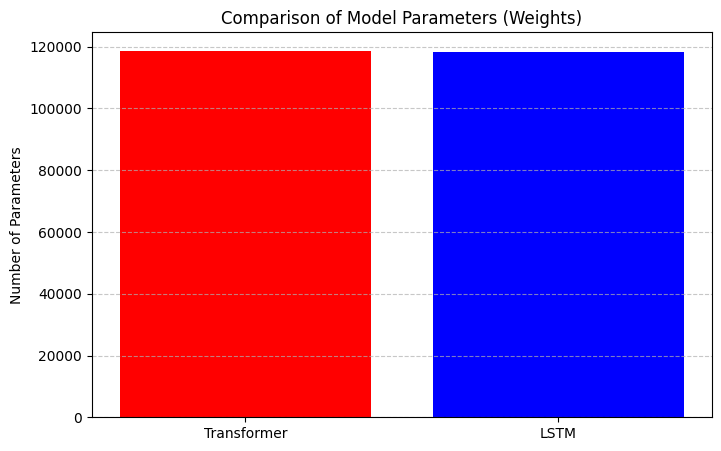

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

transformer_params = count_parameters(transformer_model)
lstm_params = count_parameters(lstm_model)

print(f'Transformer Total Trainable Parameters: {transformer_params:,}')
print(f'LSTM Total Trainable Parameters:        {lstm_params:,}')

# Simple visualization of model weight comparison
labels = ['Transformer', 'LSTM']
params = [transformer_params, lstm_params]

plt.figure(figsize=(8, 5))
plt.bar(labels, params, color=['red', 'blue'])
plt.title('Comparison of Model Parameters (Weights)')
plt.ylabel('Number of Parameters')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()